# E42 — A perna que falta: a cascata calibrada

Dois mundos, a mesma contagem conjunta e as mesmas marginais: um por choque comum, outro por
propagação. O que cada leitura vê --- e o que só a intervenção devolve.

In [1]:
import sys
sys.path.insert(0, "lib")

import numpy as np
import matplotlib.pyplot as plt

from frevolab import cascata, graficos

SEMENTE = 109          # <- brinque com:
DIAS = 6450
JANELA = 3
LAGS = (0, 1, 2)
TAXA_CONJUNTA = 0.02
MARG = 0.04
SORTES = 30

In [2]:
# As sortes: para cada uma, um mundo de choque e uma cascata calibrada contra ele ---
# com a taxa propria de B ajustada para a marginal de B casar antes da calibracao final.
linhas = []
for i in range(SORTES):
    ch = cascata.mundo_choque(DIAS, TAXA_CONJUNTA, MARG, MARG, semente=SEMENTE + 100 + i)
    alvo = cascata.pares_de_alinhamento(ch, JANELA).size
    alvo_b = float(ch["romp_b"].mean())
    q0 = cascata.calibra_transmissao(DIAS, MARG, MARG, LAGS, alvo, janela=JANELA,
                                     semente=SEMENTE + 200 + i)
    taxa_propria = max(0.005, alvo_b - MARG * q0)
    q = cascata.calibra_transmissao(DIAS, MARG, taxa_propria, LAGS, alvo, janela=JANELA,
                                    semente=SEMENTE + 200 + i)
    ca = cascata.mundo_cascata(DIAS, MARG, taxa_propria, LAGS, q, semente=SEMENTE + 200 + i)
    pares_h = cascata.pares_de_alinhamento(ch, JANELA)
    pares_c = cascata.pares_de_alinhamento(ca, JANELA)
    mortas_h = int(ch["romp_b"].sum()) - int(cascata.bloqueia_a(ch)["romp_b"].sum())
    mortas_c = int(ca["romp_b"].sum()) - int(cascata.bloqueia_a(ca)["romp_b"].sum())
    linhas.append({"conjuntas_h": pares_h.size, "conjuntas_c": pares_c.size, "q": q,
                   "lag0_h": float((pares_h == 0).mean()), "lag0_c": float((pares_c == 0).mean()),
                   "assim_h": float(pares_h.mean()), "assim_c": float(pares_c.mean()),
                   "b_h": int(ch["romp_b"].sum()), "b_c": int(ca["romp_b"].sum()),
                   "mortas_h": mortas_h, "mortas_c": mortas_c})
med = lambda k: float(np.median([l[k] for l in linhas]))
q25 = lambda k: float(np.quantile([l[k] for l in linhas], 0.25))
q75 = lambda k: float(np.quantile([l[k] for l in linhas], 0.75))
print("conjuntas: choque %.0f | cascata %.0f" % (med("conjuntas_h"), med("conjuntas_c")))
print("lag zero: choque %.3f | cascata %.3f" % (med("lag0_h"), med("lag0_c")))
print("assimetria media: choque %+.3f | cascata %+.3f" % (med("assim_h"), med("assim_c")))
print("rompimentos de B: choque %.0f | cascata %.0f" % (med("b_h"), med("b_c")))
print("transmissao calibrada (mediana): %.4f" % med("q"))
print("mortas pelo bloqueio: choque %.1f [%.0f; %.0f] | cascata %.1f [%.0f; %.0f]" % (
    med("mortas_h"), q25("mortas_h"), q75("mortas_h"),
    med("mortas_c"), q25("mortas_c"), q75("mortas_c")))

conjuntas: choque 160 | cascata 159
lag zero: choque 0.833 | cascata 0.311
assimetria media: choque +0.020 | cascata +0.715
rompimentos de B: choque 257 | cascata 276
transmissao calibrada (mediana): 0.4727
mortas pelo bloqueio: choque 0.0 [0; 0] | cascata 120.0 [108; 133]


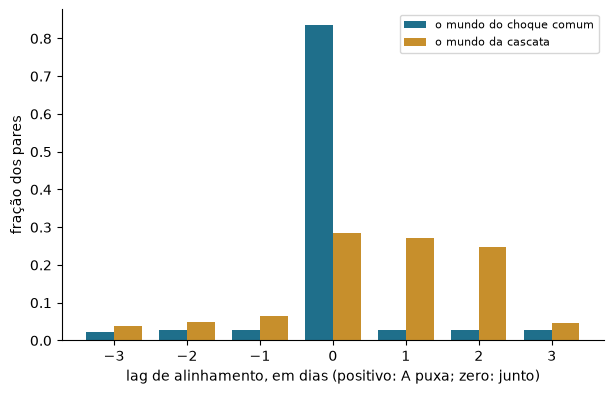

In [3]:
# Figura 1: os histogramas de alinhamento dos dois mundos.
eixo = np.arange(-JANELA, JANELA + 1)
hist_h = np.zeros(eixo.size)
hist_c = np.zeros(eixo.size)
taxa_propria_med = max(0.005, MARG + TAXA_CONJUNTA - MARG * med("q"))
for i in range(SORTES):
    ch = cascata.mundo_choque(DIAS, TAXA_CONJUNTA, MARG, MARG, semente=SEMENTE + 100 + i)
    ca = cascata.mundo_cascata(DIAS, MARG, taxa_propria_med, LAGS, med("q"), semente=SEMENTE + 200 + i)
    ph = cascata.pares_de_alinhamento(ch, JANELA)
    pc = cascata.pares_de_alinhamento(ca, JANELA)
    for k, lag in enumerate(eixo):
        hist_h[k] += (ph == lag).mean()
        hist_c[k] += (pc == lag).mean()
hist_h /= SORTES
hist_c /= SORTES
fig, ax = plt.subplots(figsize=(7.0, 4.3))
larg = 0.38
ax.bar(eixo - larg / 2, hist_h, larg, color="#1f6f8b", label="o mundo do choque comum")
ax.bar(eixo + larg / 2, hist_c, larg, color="#c78f2c", label="o mundo da cascata")
ax.set_xlabel("lag de alinhamento, em dias (positivo: A puxa; zero: junto)")
ax.set_ylabel("fração dos pares")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
graficos.salvar(fig, "E42_cascata", 1)
plt.show()

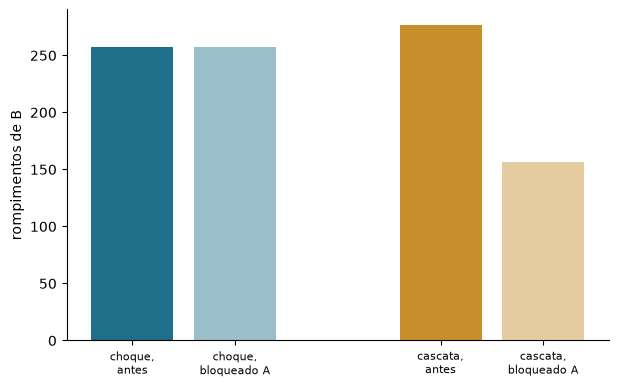

In [4]:
# Figura 2: a intervencao --- os rompimentos de B antes e depois do bloqueio de A.
antes_h = med("b_h")
depois_h = antes_h - med("mortas_h")
antes_c = med("b_c")
depois_c = antes_c - med("mortas_c")
fig, ax = plt.subplots(figsize=(7.0, 4.3))
pos = [0, 1, 3, 4]
vals = [antes_h, depois_h, antes_c, depois_c]
cores = ["#1f6f8b", "#1f6f8b", "#c78f2c", "#c78f2c"]
alphas = [1.0, 0.45, 1.0, 0.45]
for x, v, cor, alfa in zip(pos, vals, cores, alphas):
    ax.bar(x, v, 0.8, color=cor, alpha=alfa)
ax.set_xticks(pos)
ax.set_xticklabels(["choque,\nantes", "choque,\nbloqueado A",
                    "cascata,\nantes", "cascata,\nbloqueado A"], fontsize=8)
ax.set_ylabel("rompimentos de B")
ax.spines[["top", "right"]].set_visible(False)
graficos.salvar(fig, "E42_cascata", 2)
plt.show()

In [5]:
# Leitura visual das figuras (declaratória, contra o PNG):
# 1) o choque concentra quase tudo no zero; a cascata espalha entre zero, um e dois --- o
#    alinhamento VE o atraso da propagacao;
# 2) as barras claras: a do choque nao desce (zero mortas), a da cascata desce pela metade ---
#    a fracao que depende de A so existe do lado da intervencao.

In [6]:
# O que sai do laboratório e o que o livro cita.
resultado = {"cascata_choque_conjuntas": round(med("conjuntas_h"), 1),
             "cascata_cascata_conjuntas": round(med("conjuntas_c"), 1),
             "cascata_transmissao_calibrada": round(med("q"), 4),
             "cascata_lag_zero_choque": round(med("lag0_h"), 3),
             "cascata_lag_zero_cascata": round(med("lag0_c"), 3),
             "cascata_assimetria_choque": round(med("assim_h"), 3),
             "cascata_assimetria_cascata": round(med("assim_c"), 3),
             "cascata_choque_b": round(med("b_h"), 1),
             "cascata_cascata_b": round(med("b_c"), 1),
             "cascata_choque_mortas": round(med("mortas_h"), 1),
             "cascata_choque_mortas_max": round(q75("mortas_h"), 1),
             "cascata_cascata_mortas": round(med("mortas_c"), 1),
             "cascata_cascata_mortas_min": round(q25("mortas_c"), 1),
             "cascata_cascata_mortas_max": round(q75("mortas_c"), 1)}

import json
from pathlib import Path
caminho = Path("lab/resultados/E42_cascata.json")
caminho.write_text(json.dumps(resultado, indent=1, ensure_ascii=False, sort_keys=True), encoding="utf-8")
print(json.dumps(resultado, ensure_ascii=False, indent=1, sort_keys=True))

{
 "cascata_assimetria_cascata": 0.715,
 "cascata_assimetria_choque": 0.02,
 "cascata_cascata_b": 276.5,
 "cascata_cascata_conjuntas": 159.0,
 "cascata_cascata_mortas": 120.0,
 "cascata_cascata_mortas_max": 133.2,
 "cascata_cascata_mortas_min": 107.5,
 "cascata_choque_b": 257.0,
 "cascata_choque_conjuntas": 160.0,
 "cascata_choque_mortas": 0.0,
 "cascata_choque_mortas_max": 0.0,
 "cascata_lag_zero_cascata": 0.311,
 "cascata_lag_zero_choque": 0.833,
 "cascata_transmissao_calibrada": 0.4727
}
